# Import Packages

In [1]:
using DifferentialEquations
using OrdinaryDiffEq
using DiffEqBase
using Sundials
using ODEInterfaceDiffEq
using Plots
using Measures
using CSV
using DataFrames
using EasyFit
using StatsPlots
using LinearAlgebra
using Random
using Distributions
using OrdinaryDiffEq
Random.seed!(145975);
using KernelDensity
using LaTeXStrings
using StatsBase
using JLD2
using HypothesisTests
using LaTeXStrings
using Trapz
using DataFrames, GLM, StatsBase
using Polynomials 
using Trapz
using EasyFit
using LsqFit


In [2]:
include("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\BayesianInference\\FunctionsBayesInfs.jl")
include("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\InitalParameterFitPriorDef\\ModelFunctionsAll.jl")
include("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ComputationalBayesianOED\\FunctionsBayesOED.jl")

include("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\FunctionsInferenceScallable.jl")

simDwnExp2 (generic function with 2 methods)

# Inference on all Experiments Results

### Load Posteriors, Uncertainty Predictions, Posterior Analysis and Simulations

In [5]:
# Load Posteriors
cns = ["06","08","16","32","60","64","83","128","131","180","256","296","400"]
cns2 = [cns[i][1:end-1]*"."*cns[i][end] for i in 1:length(cns)]
pyrs = [0.6, 0.8, 1.6, 3.2, 6, 6.4, 8.3, 12.8, 13.1, 18, 25.6, 29, 40]


mainP = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\"

postersItr1 = Array{Any}(undef, length(cns))
postersCutItr1 = Array{Any}(undef, length(cns))

postersItr2 = Array{Any}(undef, length(cns))
postersCutItr2 = Array{Any}(undef, length(cns))

postersItr3 = Array{Any}(undef, length(cns))
postersCutItr3 = Array{Any}(undef, length(cns))

for i in 1:length(cns)
    if isfile(mainP*"PosteriorCompetitiveRepressionExpScal_Iter1All_"*cns[i]*"_Try1.csv")
        postersItr1[i] = Matrix(CSV.read(mainP*"PosteriorCompetitiveRepressionExpScal_Iter1All_"*cns[i]*"_Try1.csv", DataFrame));
        postersCutItr1[i] = hcat(postersItr1[i][:,1], postersItr1[i][:,3:12], postersItr1[i][:,15:end])
    end

    if isfile(mainP*"PosteriorCompetitiveRepressionExpScal_Iter2All_"*cns[i]*"_Try1.csv")
        postersItr2[i] = Matrix(CSV.read(mainP*"PosteriorCompetitiveRepressionExpScal_Iter2All_"*cns[i]*"_Try1.csv", DataFrame));
        postersCutItr2[i] = hcat(postersItr2[i][:,1], postersItr2[i][:,3:12], postersItr2[i][:,15:end])
    end

    if isfile(mainP*"PosteriorCompetitiveRepressionExpScal_Iter3All_"*cns[i]*"_Try1.csv")
        postersItr3[i] = Matrix(CSV.read(mainP*"PosteriorCompetitiveRepressionExpScal_Iter3All_"*cns[i]*"_Try1.csv", DataFrame));
        postersCutItr3[i] = hcat(postersItr3[i][:,1], postersItr3[i][:,3:12], postersItr3[i][:,15:end])
    end
end

priorTheta, priotY0, sampsTh, sampsY0 = genPriorSamps(8000);
priorInfer1 =  hcat(sampsTh,sampsY0);

priorInfer2 =  Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorCompetitiveRepressionExpScal_Iter1_Try1.csv", DataFrame));

priorInfer3 =  Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorCompetitiveRepressionExpScal_Iter2_Try1.csv", DataFrame));

priorInfer4 =  Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorCompetitiveRepressionExpScal_Iter3_Try1.csv", DataFrame));

In [ ]:
global tsC2 = vcat(0, collect(15:5:395));
global ts = 0:tsC2[end];
global samps = convert.(Int, tsC2);



pyrs = [0.6, 0.8, 1.6, 3.2, 6, 6.4, 8.3, 12.8, 13.1, 18, 25.6, 29, 40]
# pyrs = [0.6, 0.8, 1.6, 6, 6.4, 8.3, 12.8, 13.1, 18, 25.6, 29, 40] # At each iteration we remove past experiments

objs1 = zeros(1,length(pyrs))
objs2 = zeros(1,length(pyrs))
objs3 = zeros(1,length(pyrs))

for i in 1:length(pyrs)
    global sampsTh = priorInfer1[:,1:14];
    global sampsY0 = priorInfer1[:,15:end];
    objs1[i] = CompRepUtil_Entro_OEDmc2([pyrs[i]])
end

for i in 1:length(pyrs)
    global sampsTh = priorInfer2[:,1:14];
    global sampsY0 = priorInfer2[:,15:end];
    objs2[i] = CompRepUtil_Entro_OEDmc2([pyrs[i]])
end

for i in 1:length(pyrs)
    global sampsTh = priorInfer3[:,1:14];
    global sampsY0 = priorInfer3[:,15:end];
    objs3[i] = CompRepUtil_Entro_OEDmc2([pyrs[i]])
end

CSV.write("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\PredictUncertIter1.csv", DataFrame(objs1, :auto))
CSV.write("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\PredictUncertIter2.csv", DataFrame(objs2, :auto))
CSV.write("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\PredictUncertIter3.csv", DataFrame(objs3, :auto))

13-element Vector{Float64}:
  0.6
  0.8
  1.6
  3.2
  6.0
  6.4
  8.3
 12.8
 13.1
 18.0
 25.6
 29.0
 40.0

In [ ]:
global tsC2 = vcat(0, collect(15:5:395));
global ts = 0:tsC2[end];
global samps = convert.(Int, tsC2);



pyrs2 = collect(0.1:0.1:40)
# pyrs = [0.6, 0.8, 1.6, 6, 6.4, 8.3, 12.8, 13.1, 18, 25.6, 29, 40] # At each iteration we remove past experiments

objs1F = zeros(1,length(pyrs2))
objs2F = zeros(1,length(pyrs2))
objs3F = zeros(1,length(pyrs2))

for i in 1:length(pyrs2)
    global sampsTh = priorInfer1[:,1:14];
    global sampsY0 = priorInfer1[:,15:end];
    objs1F[i] = CompRepUtil_Entro_OEDmc2([pyrs2[i]])
end

for i in 1:length(pyrs2)
    global sampsTh = priorInfer2[:,1:14];
    global sampsY0 = priorInfer2[:,15:end];
    objs2F[i] = CompRepUtil_Entro_OEDmc2([pyrs2[i]])
end

for i in 1:length(pyrs2)
    global sampsTh = priorInfer3[:,1:14];
    global sampsY0 = priorInfer3[:,15:end];
    objs3F[i] = CompRepUtil_Entro_OEDmc2([pyrs2[i]])
end

CSV.write("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\PredictUncertIter1F.csv", DataFrame(objs1F, :auto))
CSV.write("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\PredictUncertIter2F.csv", DataFrame(objs2F, :auto))
CSV.write("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\PredictUncertIter3F.csv", DataFrame(objs3F, :auto))

In [7]:
global tsC2 = vcat(0, collect(15:5:395));
global ts = 0:tsC2[end];
global samps = convert.(Int, tsC2);

pyrs2 = collect(0.1:0.1:40)

objs4F = zeros(1,length(pyrs2))

for i in 1:length(pyrs2)
    global sampsTh = priorInfer4[:,1:14];
    global sampsY0 = priorInfer4[:,15:end];
    objs4F[i] = CompRepUtil_Entro_OEDmc2([pyrs2[i]])
end

CSV.write("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\PredictUncertIter4F.csv", DataFrame(objs4F, :auto))

"C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\PredictUncertIter4F.csv"

In [21]:
# LOAD SIMULATIONS
mainD = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ProcessedData\\";

datsD = ["3Mil_0-6mMPyr_Dat","3Mil_0-8mMPyr_Dat","3Mil_1-6mMPyr_Dat","3Mil_3-2mMPyr_Dat", "3Mil_6-0mMPyr_Dat","3Mil_6-4mMPyr_Dat","3Mil_8-3mMPyr_Dat","3Mil_12-8mMPyr_Dat","3Mil_13-1mMPyr_Dat","3Mil_18-0mMPyr_Dat","3Mil_25-6mMPyr_Dat","3Mil_29-6mMPyr_Dat","3Mil_40-0mMPyr_Dat"]

allD = [Matrix(CSV.read(mainD*datsD[i]*".csv", DataFrame)) for i in 1:length(datsD)];

In [70]:
# ITERATION 1

rep = true
nSamps = 4000


if isfile("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\SimsItr1AllExps.jld") && rep == false
    println(1)

    tt1 = JLD2.load("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\SimsItr1AllExps.jld");
    SimsItr1All = tt1["SimsItr1All"];


    tt1 = JLD2.load("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\SimsItr1AllExpsGOFm.jld");
    GOFItr1All = tt1["GOFItr1All"];
    

elseif !isfile("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\SimsItr1AllExps.jld") || rep == true
    println(2)
    SimsItr1All = Array{Any}(undef, 2, length(postersItr1), length(datsD))

    for i in 1:length(postersItr1)

        poster1 = postersItr1[i]
        
        for j in 1:length(datsD)
            expSA = datsD[j]
            PyrConsA = pyrs[j]
            
            Random.seed!(78956321)
            SimsItr1All[1,i,j], SimsItr1All[2,i,j] = simDwnExp2(expSA, datsD, PyrConsA, nSamps, poster1, allD, false)
        end
    end

    JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\SimsItr1AllExps.jld", "SimsItr1All", SimsItr1All)


    GOFItr1All = Array{Any}(undef, 2, length(postersItr1), length(datsD)); # First BIC, second nRMSE

    for i in 1:length(postersItr1)   
        for j in 1:length(datsD)

            tmp_BIC = zeros(length(SimsItr1All[1,i,j]))
            tmp_nRMSE = zeros(length(SimsItr1All[1,i,j]))

            tmp_m = allD[j][2:end,4]
            tmp_s = allD[j][2:end,5]
            tin = length(tmp_m)

            for s in 1:length(SimsItr1All[1,i,j])
                tmp_p = SimsItr1All[1,i,j][s][(80-tin)+1:end,13,1]

                tmp_BIC[s] = sum(((tmp_p-tmp_m).^2)./(tmp_s.^2)) .+ (11*log(length(tmp_p))) # BIC_Lac_F
                tmp_nRMSE[s] = sqrt(sum(((tmp_p-tmp_m).^2)./(tmp_s.^2))/length(tmp_p)) .+ (log(11*log(length(tmp_p))))
            end

            GOFItr1All[1,i,j] = tmp_BIC;
            GOFItr1All[2,i,j] = tmp_nRMSE;
        end
    end

    JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\SimsItr1AllExpsGOFm.jld", "GOFItr1All", GOFItr1All)

end

2


In [ ]:
# ITERATION 2

rep = false
nSamps = 4000


if isfile("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\SimsItr2AllExps.jld") && rep == false
    println(1)

    tt1 = JLD2.load("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\SimsItr2AllExps.jld");
    SimsItr2All = tt1["SimsItr2All"];


    tt1 = JLD2.load("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\SimsItr2AllExpsGOFm.jld");
    GOFItr2All = tt1["GOFItr2All"];
    

elseif !isfile("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\SimsItr2AllExps.jld") || rep == true
    println(2)
    SimsItr2All = Array{Any}(undef, 2, length(postersItr2), length(datsD))

    for i in 1:length(postersItr2)

        poster1 = postersItr2[i]
        
        for j in 1:length(datsD)
            expSA = datsD[j]
            PyrConsA = pyrs[j]
            
            Random.seed!(78956321)
            SimsItr2All[1,i,j], SimsItr2All[2,i,j] = simDwnExp2(expSA, datsD, PyrConsA, nSamps, poster1, allD, false)
        end
    end

    JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\SimsItr2AllExps.jld", "SimsItr2All", SimsItr2All)


    GOFItr2All = Array{Any}(undef, 2, length(postersItr2), length(datsD)); # First BIC, second nRMSE

    for i in 1:length(postersItr2)   
        for j in 1:length(datsD)

            tmp_BIC = zeros(length(SimsItr2All[1,i,j]))
            tmp_nRMSE = zeros(length(SimsItr2All[1,i,j]))

            tmp_m = allD[j][2:end,4]
            tmp_s = allD[j][2:end,5]
            tin = length(tmp_m)

            for s in 1:length(SimsItr2All[1,i,j])
                tmp_p = SimsItr2All[1,i,j][s][(80-tin)+1:end,13,1]

                tmp_BIC[s] = sum(((tmp_p-tmp_m).^2)./(tmp_s.^2)) .+ (11*log(length(tmp_p))) # BIC_Lac_F
                tmp_nRMSE[s] = sqrt(sum(((tmp_p-tmp_m).^2)./(tmp_s.^2))/length(tmp_p)) .+ (log(11*log(length(tmp_p))))
            end

            GOFItr2All[1,i,j] = tmp_BIC;
            GOFItr2All[2,i,j] = tmp_nRMSE;
        end
    end

    JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\SimsItr2AllExpsGOFm.jld", "GOFItr2All", GOFItr2All)

end

2


In [55]:
# ITERATION 3

rep = true
nSamps = 4000


if isfile("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\SimsItr3AllExps.jld") && rep == false
    println(1)

    tt1 = JLD2.load("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\SimsItr3AllExps.jld");
    SimsItr3All = tt1["SimsItr3All"];


    tt1 = JLD2.load("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\SimsItr3AllExpsGOFm.jld");
    GOFItr3All = tt1["GOFItr3All"];
    

elseif !isfile("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\SimsItr3AllExps.jld") || rep == true
    println(2)
    SimsItr3All = Array{Any}(undef, 2, length(postersItr3), length(datsD))

    for i in 1:length(postersItr3)
        if i != 3
            poster1 = postersItr3[i]
            
            for j in 1:length(datsD)
                expSA = datsD[j]
                PyrConsA = pyrs[j]
                
                Random.seed!(78956321)
                SimsItr3All[1,i,j], SimsItr3All[2,i,j] = simDwnExp2(expSA, datsD, PyrConsA, nSamps, poster1, allD, false)
            end
        end
    end

    JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\SimsItr3AllExps.jld", "SimsItr3All", SimsItr3All)


    GOFItr3All = Array{Any}(undef, 2, length(postersItr3), length(datsD)); # First BIC, second nRMSE

    for i in 1:length(postersItr3)   
        
        if i != 3
            
            for j in 1:length(datsD)

                tmp_BIC = zeros(length(SimsItr3All[1,i,j]))
                tmp_nRMSE = zeros(length(SimsItr3All[1,i,j]))

                tmp_m = allD[j][2:end,4]
                tmp_s = allD[j][2:end,5]
                tin = length(tmp_m)

                for s in 1:length(SimsItr3All[1,i,j])
                    tmp_p = SimsItr3All[1,i,j][s][(80-tin)+1:end,13,1]

                    tmp_BIC[s] = sum(((tmp_p-tmp_m).^2)./(tmp_s.^2)) .+ (11*log(length(tmp_p))) # BIC_Lac_F
                    tmp_nRMSE[s] = sqrt(sum(((tmp_p-tmp_m).^2)./(tmp_s.^2))/length(tmp_p)) .+ (log(11*log(length(tmp_p))))
                end

                GOFItr3All[1,i,j] = tmp_BIC;
                GOFItr3All[2,i,j] = tmp_nRMSE;
            end
        end
    end

    JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\SimsItr3AllExpsGOFm.jld", "GOFItr3All", GOFItr3All)

end

2


# Inference on single OED Experiments

In [3]:
priorTheta, priotY0, sampsTh, sampsY0 = genPriorSamps(8000);
priorInfer1 =  hcat(sampsTh,sampsY0);

priorInfer2 =  Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorCompetitiveRepressionExpScal_Iter1_Try1.csv", DataFrame));

priorInfer3 =  Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorCompetitiveRepressionExpScal_Iter2_Try1.csv", DataFrame));

priorInfer4 =  Matrix(CSV.read("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorCompetitiveRepressionExpScal_Iter3_Try1.csv", DataFrame));

In [ ]:
global tsC2 = vcat(0, collect(15:5:395));
global ts = 0:tsC2[end];
global samps = convert.(Int, tsC2);


pyrs = [0.6, 0.8, 1.6, 3.2, 6, 6.4, 8.3, 12.8, 13.1, 18, 25.6, 29, 40]

PRIS = [priorInfer1, priorInfer2, priorInfer3, priorInfer4]
OBJ = Array{Any}(undef, 4)

for j in 1:4
    objs = zeros(length(pyrs))

    global sampsTh = PRIS[j][:,1:14];
    global sampsY0 = PRIS[j][:,15:end];

    for i in 1:length(pyrs)
        objs[i] = CompRepUtil_Entro_OEDmc2([pyrs[i]])
    end
    OBJ[j] = objs

end

JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\ObjectiveFunctExperiments_PerIter.jld", "OBJ", OBJ)

# Predictions Pyr VS Lac

In [4]:
mainP = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\Paper\\RawData_DiffPyr\\"

expsP = [["0.0Pyr_2025_04_18_DGC_HepG2_3Mil_0mMPyruvate_NewTryControl1","0.0Pyr_2025_04_18_DGC_HepG2_3Mil_0mMPyruvate_NewTryControl2","0.0Pyr_2025_04_18_DGC_HepG2_3Mil_0mMPyruvate_NewTryControl3"],
         ["0.6Pyr_2025_03_26_DGC_HepG2_3Mil_0.6mMPyruvate_NewTryControl1","0.6Pyr_2025_03_24_DGC_HepG2_3Mil_0.6mMPyruvate_NewTryControl4","0.6Pyr_2025_03_24_DGC_HepG2_3Mil_0.6mMPyruvate_NewTryControl3"],
         ["0.8Pyr_2025_03_13_DGC_HepG2_3Mil_0.8mMPyruvate_NewTryControl1","0.8Pyr_2025_03_23_DGC_HepG2_3Mil_0.8mMPyruvate_NewTryControl1","0.8Pyr_2025_03_23_DGC_HepG2_3Mil_0.8mMPyruvate_NewTryControl2"],
         ["1.6Pyr_2025_03_26_DGC_HepG2_3Mil_1.6mMPyruvate_NewTryControl2","1.6Pyr_2025_03_24_DGC_HepG2_3Mil_1.6mMPyruvate_NewTryControl1","1.6Pyr_2025_03_26_DGC_HepG2_3Mil_1.6mMPyruvate_NewTryControl1"],
         ["3.2Pyr_2025_02_05_DGC_HepG2_3Mil_3.2mMPyruvate_NewTryControl","3.2Pyr_2025_02_05_DGC_HepG2_3Mil_3.2mMPyruvate_NewTryControl2","3.2Pyr_2025_02_14_DGC_HepG2_3Mil_3.2mMPyruvate_NewTryControl1"],
        #  ["4.9Pyr_2025_07_18_DGC_HepG2_3Mil_4.9mMPyruvate_NewTryControl2","4.9Pyr_2025_07_18_DGC_HepG2_3Mil_4.9mMPyruvate_NewTryControl3","4.9Pyr_2025_07_22_DGC_HepG2_3Mil_4.9mMPyruvate_NewTryControl2"],
         ["6.0Pyr_2025_04_18_DGC_HepG2_3Mil_6mMPyruvate_NewTryControl1","6.0Pyr_2025_04_18_DGC_HepG2_3Mil_6mMPyruvate_NewTryControl2","6.0Pyr_2025_05_09_DGC_HepG2_3Mil_6mMPyruvate_NewTryControl1_NEW"],
         ["6.4Pyr_2025_03_12_DGC_HepG2_3Mil_6.4mMPyruvate_NewTryControl1","6.4Pyr_2025_03_12_DGC_HepG2_3Mil_6.4mMPyruvate_NewTryControl2","6.4Pyr_2025_03_12_DGC_HepG2_3Mil_6.4mMPyruvate_NewTryControl3"],
         ["8.3Pyr_2025_06_12_DGC_HepG2_3Mil_8.3mMPyruvate_NewTryControl1","8.3Pyr_2025_06_12_DGC_HepG2_3Mil_8.3mMPyruvate_NewTryControl3","8.3Pyr_2025_06_12_DGC_HepG2_3Mil_8.3mMPyruvate_NewTryControl4"],
         ["12.8Pyr_2025_03_12_DGC_HepG2_3Mil_12.8mMPyruvate_NewTryControl1","12.8Pyr_2025_03_13_DGC_HepG2_3Mil_12.8mMPyruvate_NewTryControl2","12.8Pyr_2025_03_13_DGC_HepG2_3Mil_12.8mMPyruvate_NewTryControl3"],
         ["13.1Pyr_2025_08_04_DGC_HepG2_3Mil_13.1mMPyruvate_NewTryControl1","13.1Pyr_2025_08_04_DGC_HepG2_3Mil_13.1mMPyruvate_NewTryControl2","13.1Pyr_2025_08_04_DGC_HepG2_3Mil_13.1mMPyruvate_NewTryControl3"],
         ["18.0Pyr_2025_07_09_DGC_HepG2_3Mil_18mMPyruvate_NewTryControl2","18.0Pyr_2025_07_09_DGC_HepG2_3Mil_18mMPyruvate_NewTryControl3","18.0Pyr_2025_07_09_DGC_HepG2_3Mil_18mMPyruvate_NewTryControl4"],
         ["25.6Pyr_2025_03_20_DGC_HepG2_3Mil_25.6mMPyruvate_NewTryControl1","25.6Pyr_2025_03_20_DGC_HepG2_3Mil_25.6mMPyruvate_NewTryControl2","25.6Pyr_2025_03_20_DGC_HepG2_3Mil_25.6mMPyruvate_NewTryControl3"],
         ["29.6Pyr_2025_06_13_DGC_HepG2_3Mil_29.6mMPyruvate_NewTryControl1","29.6Pyr_2025_06_13_DGC_HepG2_3Mil_29.6mMPyruvate_NewTryControl2","29.6Pyr_2025_06_13_DGC_HepG2_3Mil_29.6mMPyruvate_NewTryControl3"],
         ["40.0Pyr_2025_03_21_DGC_HepG2_3Mil_40mMPyruvate_NewTryControl1","40.0Pyr_2025_03_21_DGC_HepG2_3Mil_40mMPyruvate_NewTryControl2","40.0Pyr_2025_03_21_DGC_HepG2_3Mil_40mMPyruvate_NewTryControl3"]]

# cns = [0,0.6,0.8,1.6,3.2,4.9,6,6.4,8.3,12.8,13.1,18,25.6,29,40]
cns = [0,0.6,0.8,1.6,3.2,6,6.4,8.3,12.8,13.1,18,25.6,29.6,40]

Matrix(CSV.read(mainP*expsP[5][1]*".csv", DataFrame))

80×5 Matrix{Any}:
   0  8908.21      0.432911   missing  "3.2 Good"
   5  8002.09      0.0990377  missing  missing
  10  7106.47     -2.5639     missing  missing
  15  6998.51     24.4311     missing  missing
  20  6211.92     35.1748     missing  missing
  25  5565.78     47.1715     missing  missing
  30  5022.72     57.3        missing  missing
  35  4512.38     56.0712     missing  missing
  40  4058.06     63.2657     missing  missing
  45  3717.37     63.7562     missing  missing
   ⋮                                   
 355     3.75297   1.02128    missing  missing
 360     4.25025  -1.79685    missing  missing
 365    -3.7075   -0.412118   missing  missing
 370     9.67086  -3.45491    missing  missing
 375    -9.67301   2.02882    missing  missing
 380     4.0676   -2.84821    missing  missing
 385     2.1862    0.689267   missing  missing
 390     1.83978  -2.34216    missing  missing
 395    -1.31021   3.82482    missing  missing

In [5]:
datmeA = Array{Any}(undef, length(expsP), 3)
for i in 1:length(expsP)
    for j in 1:3
        datmeA[i,j] = Matrix(CSV.read(mainP*expsP[i][j]*".csv", DataFrame))
    end
end

#### Extrapolate P0

In [6]:
using Polynomials 
using Trapz
using EasyFit
using LsqFit

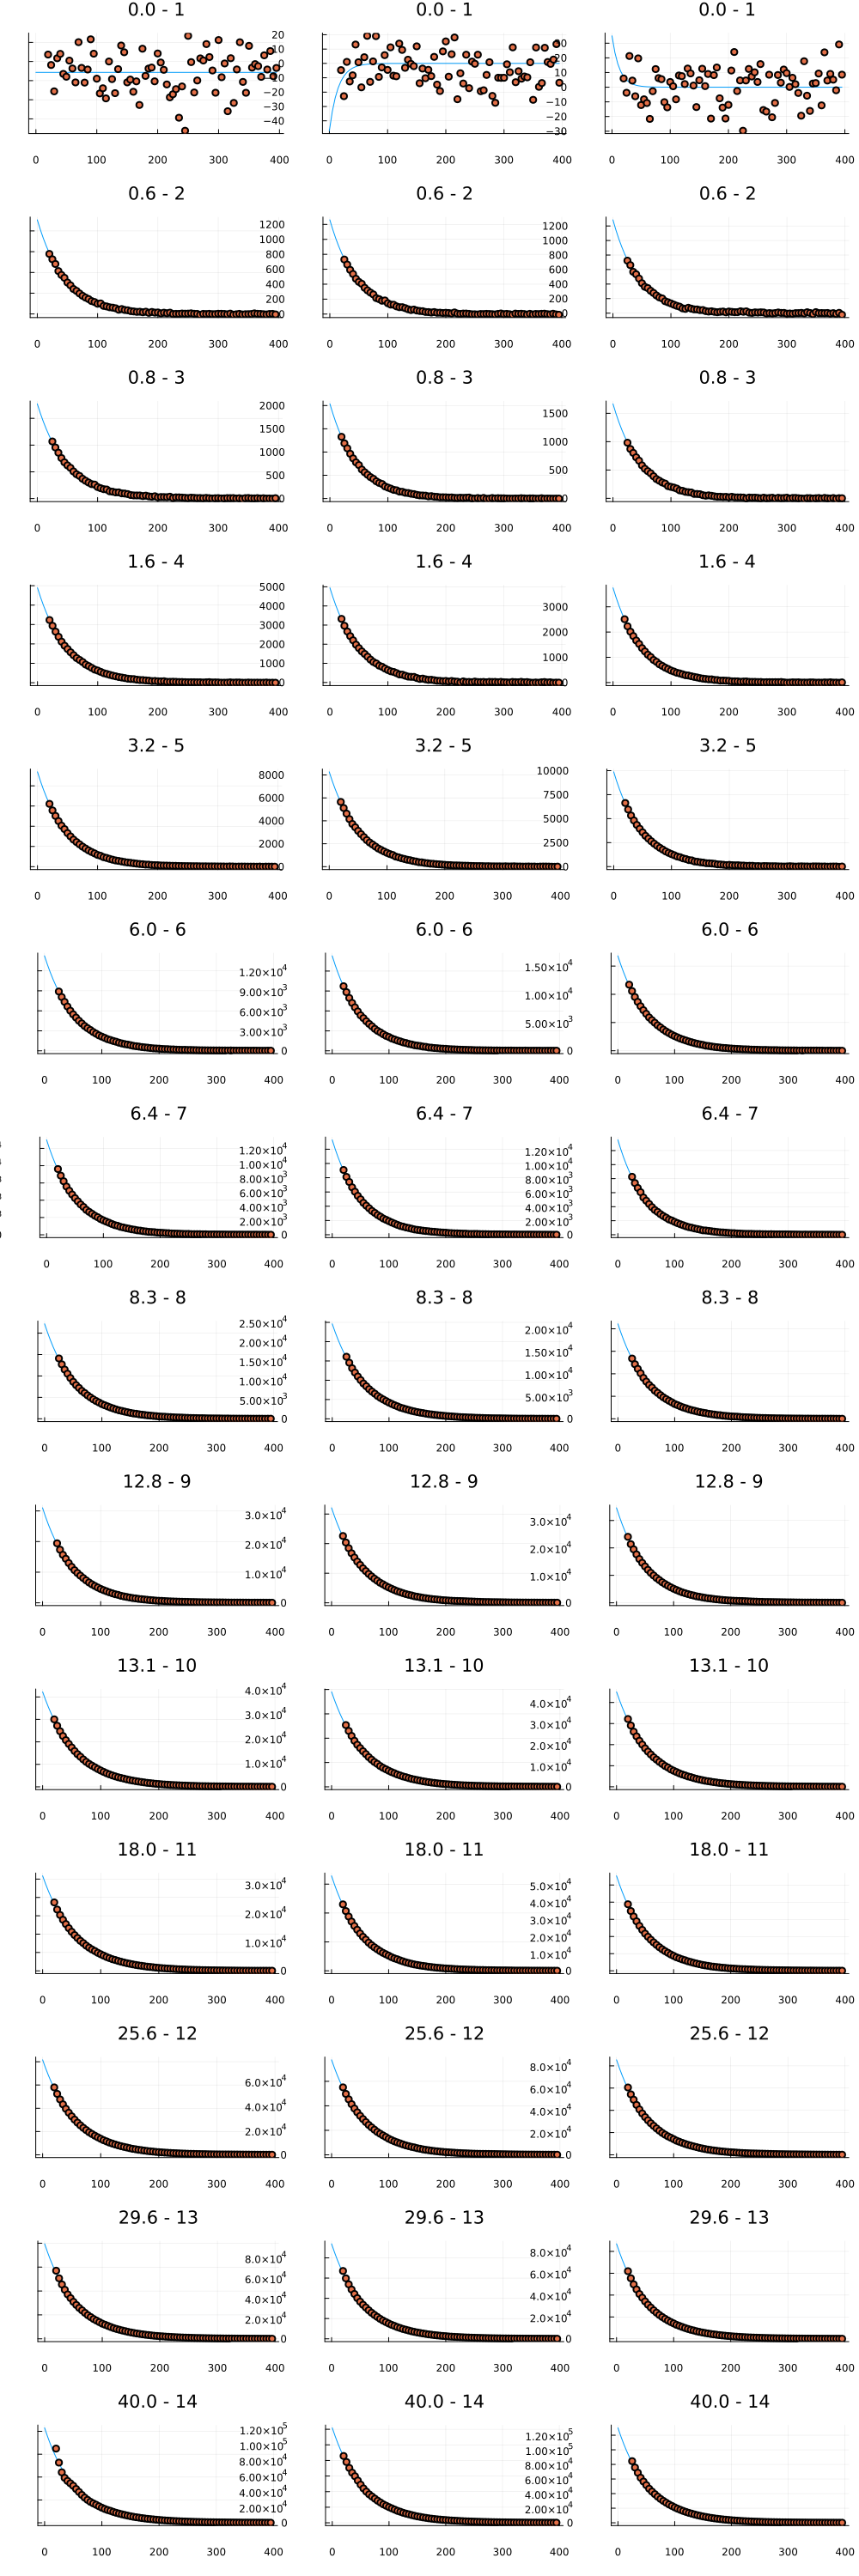

In [7]:
# Fit T1, extract P0
T1s = zeros(length(expsP), 3);
P0s = zeros(length(expsP), 3);

m(t,p) =  p[1].*exp.(-t.*p[2]);
p0 = [10000, 0.01];

pltT1 = Array{Any}(undef, length(expsP))

for i in 1:length(expsP)
    tmpPl = Array{Any}(undef, 3)
    for j in 1:3

        if (i == 2 && j == 2) || (i == 2 && j == 3) || (i == 3 && j == 1) || (i == 3 && j == 3) || (i == 6 && j == 1) || (i == 7 && j == 3) || (i == 8 && j == 1) || (i == 8 && j == 2) || 
           (i == 8 && j == 3) || (i == 9 && j == 1) || (i == 10 && j == 2) || (i == 14 && j == 3)
            t = datmeA[i,j][6:end,1];
            d = datmeA[i,j][6:end,2];
        else
            t = datmeA[i,j][5:end,1];
            d = datmeA[i,j][5:end,2];
        end

        fit = curve_fit(m, t, d, p0);

        pp=plot(datmeA[i,j][:,1], m(datmeA[i,j][:,1], coef(fit)), title=string(cns[i])*" - "*string(i), label = "")
        scatter!(t, d, label = "")

        tmpPl[j] = pp

        T1s[i,j] = 1/coef(fit)[2];
        P0s[i,j] = m(datmeA[i,j][1,1], coef(fit));

        # display(pp)

    end
    pltT1[i] = plot(tmpPl..., layout=(1,3))
end

P0s[1,:] = [mean(datmeA[1,:][i][:,2]) for i in 1:3]

plot(pltT1..., layout=(length(expsP),1), size = (1000,3000))

In [8]:
# obs = cns*0.12*ScF

ScFs = P0s./(0.12 .*cns*1000);
ScFs[1,:] .= mean(ScFs[2:end,:]);
ScFs

14×3 Matrix{Float64}:
 22.4601  22.4601  22.4601
 15.7407  17.5127  17.836
 18.4479  21.2143  17.3701
 25.4596  25.7591  19.5459
 24.4382  21.5414  25.7196
 19.7901  19.8536  23.3556
 17.8877  17.3417  17.6136
 22.2607  24.7164  21.1853
 20.1907  20.8962  22.5346
 26.8768  24.8415  28.657
 23.9642  15.2182  25.6156
 26.566   25.2282  27.805
 27.9634  26.422   24.4659
 21.6303  25.3782  27.1014

In [9]:
corDat = Array{Any}(undef, length(cns), 3)
for i in 1:length(cns)
    for j in 1:3
        corDat[i,j] = datmeA[i,j][:,2:3]./mean(ScFs[i,:])
    end
end

In [10]:
aucs = zeros(length(cns), 3)

for i in 1:length(cns)
    for j in 1:3
        if (i == 2 && j == 2) || (i == 2 && j == 3) || (i == 3 && j == 1) || (i == 3 && j == 3) || (i == 6 && j == 1) || (i == 7 && j == 3) || (i == 8 && j == 1) || (i == 8 && j == 2) || 
           (i == 8 && j == 3) || (i == 9 && j == 1) || (i == 10 && j == 2) || (i == 14 && j == 3)
            z = 6
        else
            z = 5
        end
        
        x = vcat(datmeA[i,j][1,1], datmeA[i,j][z:end,1])
        y = vcat(0, corDat[i,j][z:end,2])

        aucs[i,j] = trapz(convert.(Float64, x), convert.(Float64, y))
    end
end

In [22]:
CSV.write("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ProcessedData\\LacAUCs.csv", DataFrame(hcat(cns, aucs), ["Pyr","Lac_AUC-1","Lac_AUC-2","Lac_AUC-3"]))

"C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ProcessedData\\LacAUCs.csv"

## Simulations

In [11]:
function simDwnExp3(PyrCons, nSamps, poster)
    tsC2 = vcat(collect(0:5:395));
    ts = 0:tsC2[end];
    samps = convert.(Int, tsC2);


    postDwn = poster[StatsBase.sample(1:size(poster)[1], nSamps, replace = false),:]

    scF = 1

    simsPrior = Array{Any}(undef, nSamps);
    for i in 1:nSamps
        ivss = [round(PyrCons[1], digits = 1)*1000, 0, 0, postDwn[i,15], postDwn[i,16], postDwn[i,17], 0, 0, 0, 0, 0, round(PyrCons[1], digits = 1)*1000, 0, round(PyrCons[1], digits = 1)*1000*(scF*0.12)];;
        samps = convert.(Int, tsC2);

        SimulsAll, SimulsAll2, SimulsAll3 = PyruvateHP_NMR_SolveAllCp_Scall(ts, vcat(postDwn[i,1:13], scF, 0), ivss, samps);
        simsPrior[i] = SimulsAll;
    end


    # Dims = Up/Down, Observable, Experiment
    PriorQuant = Array{Any}(undef,2,1,1);
    lacPirorSims = zeros(size(simsPrior[1])[1], nSamps)
    [lacPirorSims[:,i] = simsPrior[i][:,13,1] for i in 1:nSamps ];
    for k in 1:1
        for m in 1:1
            PriorQuant[1,k,m] = [percentile(lacPirorSims[j,:], 99.5) for j in 1:size(lacPirorSims)[1]]; # Up
            PriorQuant[2,k,m] = [percentile(lacPirorSims[j,:], 0.5 ) for j in 1:size(lacPirorSims)[1]]; # Down
        end
    end

    return(simsPrior, PriorQuant)

end


simDwnExp3 (generic function with 1 method)

In [12]:
# LOAD SIMULATIONS
mainD = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ProcessedData\\";

datsD2 = ["3Mil_0-0mMPyr_Dat", "3Mil_0-6mMPyr_Dat","3Mil_0-8mMPyr_Dat","3Mil_1-6mMPyr_Dat","3Mil_3-2mMPyr_Dat", "3Mil_6-0mMPyr_Dat","3Mil_6-4mMPyr_Dat","3Mil_8-3mMPyr_Dat","3Mil_12-8mMPyr_Dat","3Mil_13-1mMPyr_Dat","3Mil_18-0mMPyr_Dat","3Mil_25-6mMPyr_Dat","3Mil_29-6mMPyr_Dat","3Mil_40-0mMPyr_Dat"]

allD2 = [Matrix(CSV.read(mainD*datsD2[i]*".csv", DataFrame)) for i in 1:length(datsD2)];

In [5]:
mainP = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\"

postNms = ["PosteriorCompetitiveRepressionExpScal_Iter1_Try1", "PosteriorCompetitiveRepressionExpScal_Iter2_Try1", "PosteriorCompetitiveRepressionExpScal_Iter3_Try1", "PosteriorCompetitiveRepressionExpScal_Iter4_Try1", "PosteriorCompetitiveRepressionExpScal_Iter4b_Try1"]

posters = Array{Any}(undef, length(postNms))
for i in 1:length(postNms)
    posters[i] = Matrix(CSV.read(mainP*postNms[i]*".csv", DataFrame));
end

In [14]:
rep = false
nSamps = 1000
pyrRng = 0:0.2:40


if isfile("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\SimsAllItrs.jld") && rep == false
    println(1)

    tt1 = JLD2.load("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\SimsAllItrs.jld");
    SimsItr1All = tt1["SimsItr1All"];

    tt2 = JLD2.load("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\SimsItr1AllExps_AUC.jld")
    lacSumQuantO = tt2["lacSumQuantO"];

elseif !isfile("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\SimsAllItrs.jld") || rep == true
    println(2)
    SimsItr1All = Array{Any}(undef, 2, length(posters), length(pyrRng))

    for i in 1:length(posters)

        poster1 = posters[i]
        
        for j in 1:length(pyrRng)
            PyrConsA = pyrRng[j]
            
            Random.seed!(78956321)
            SimsItr1All[1,i,j], SimsItr1All[2,i,j] = simDwnExp3(PyrConsA, nSamps, poster1)
        end
    end

    JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\SimsAllItrs.jld", "SimsItr1All", SimsItr1All)

    sumSimsO = zeros(length(posters), nSamps, length(pyrRng))

    tsC2 = vcat(collect(0:5:395));
    ts = 0:tsC2[end];
    samps = convert.(Int, tsC2);
    [sumSimsO[m,j,i] = trapz(samps, SimsItr1All[1,:,:][m,i][j][:,13,1]) for m in 1:length(posters) for i in 1:length(pyrRng) for j in 1:nSamps]

    lacSumQuantO = Array{Any}(undef,length(posters), 2, length(pyrRng));

    for k in 1:length(posters)
        for m in 1:length(pyrRng)
            lacSumQuantO[k,1,m] = percentile(sumSimsO[k,:,m], 95); # Up
            lacSumQuantO[k,2,m] = percentile(sumSimsO[k,:,m], 5 ); # Down
        end
    end

    JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\SimsItr1AllExps_AUC.jld", "lacSumQuantO", lacSumQuantO)


end

1


5×2×201 Array{Any, 3}:
[:, :, 1] =
 0.0           0.0
 5.03119e-25  -6.11345e-23
 3.18768e-22  -4.59508e-22
 2.82154e-23  -8.24549e-24
 0.0           0.0

[:, :, 2] =
 251.847   97.7749
 108.033   66.2857
  82.3768  58.6196
  81.9256  62.5118
 100.718   66.4405

[:, :, 3] =
 181.284  130.175
 130.717  103.307
 119.872  101.413
 119.329  102.744
 130.045  110.002

;;; … 

[:, :, 199] =
  45.8413   17.4569
 459.062   198.035
 139.831   126.655
 106.645    99.4031
 171.914   151.357

[:, :, 200] =
  45.7327   17.4128
 458.149   197.565
 139.463   126.318
 106.302    99.0992
 171.487   150.943

[:, :, 201] =
  45.6247   17.369
 457.242   197.1
 139.098   125.992
 105.963    98.7856
 171.064   150.549

## Simulations only experiments

In [8]:
# LOAD SIMULATIONS
mainD = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ProcessedData\\";

datsD = ["3Mil_0-0mMPyr_Dat", "3Mil_0-6mMPyr_Dat","3Mil_0-8mMPyr_Dat","3Mil_1-6mMPyr_Dat","3Mil_3-2mMPyr_Dat", "3Mil_6-0mMPyr_Dat","3Mil_6-4mMPyr_Dat","3Mil_8-3mMPyr_Dat","3Mil_12-8mMPyr_Dat","3Mil_13-1mMPyr_Dat","3Mil_18-0mMPyr_Dat","3Mil_25-6mMPyr_Dat","3Mil_29-6mMPyr_Dat","3Mil_40-0mMPyr_Dat"]

allD = [Matrix(CSV.read(mainD*datsD[i]*".csv", DataFrame)) for i in 1:length(datsD)];


[CVODES ERROR]  CVode
  At t = 0 and h = 3.25588e-014, the corrector convergence test failed repeatedly or with |h| = hmin.



In [9]:
mainP = "C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\"

postNms = ["PosteriorCompetitiveRepressionExpScal_Iter1_Try1", "PosteriorCompetitiveRepressionExpScal_Iter2_Try1", "PosteriorCompetitiveRepressionExpScal_Iter3_Try1", "PosteriorCompetitiveRepressionExpScal_Iter4_Try1", "PosteriorCompetitiveRepressionExpScal_Iter4b_Try1"]

posters = Array{Any}(undef, length(postNms))
for i in 1:length(postNms)
    posters[i] = Matrix(CSV.read(mainP*postNms[i]*".csv", DataFrame));
end

In [ ]:
rep = true
nSamps = 4000
pyrRng2 = [0, 0.6, 0.8, 1.6, 3.2, 6, 6.4, 8.3, 12.8, 13.1, 18, 25.6, 29, 40]


if isfile("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\SimsAllItrsIndExp.jld") && rep == false
    println(1)

    tt1 = JLD2.load("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\SimsAllItrsIndExp.jld");
    SimsItr1All2 = tt1["SimsItr1All2"];


elseif !isfile("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\SimsAllItrsIndExp.jld") || rep == true
    println(2)
    SimsItr1All2 = Array{Any}(undef, 2, length(posters), length(pyrRng2))

    for i in 1:length(posters)
        poster1 = posters[i]
        
        for j in 1:length(pyrRng2)
            expSA = datsD[j]
            PyrConsA = pyrRng2[j]
            
            Random.seed!(78956321)
            SimsItr1All2[1,i,j], SimsItr1All2[2,i,j] = simDwnExp2(expSA, datsD, PyrConsA, nSamps, poster1, allD, false)
        end
    end

    JLD2.save("C:\\IBECPostDocDrive\\2024_01_16_NCvsKR\\DataProcessingInference\\ExperimentalBayesianOED_Y0Measured\\Results\\PosteriorAnalysis\\SimsAllItrsIndExp.jld", "SimsItr1All2", SimsItr1All2)


end